In [1]:
library(Seurat)
library(dplyr)

Warning message:
“程辑包‘Seurat’是用R版本4.3.3 来建造的”
载入需要的程辑包：SeuratObject

Warning message:
“程辑包‘SeuratObject’是用R版本4.3.3 来建造的”
载入需要的程辑包：sp

Warning message:
“程辑包‘sp’是用R版本4.3.2 来建造的”

载入程辑包：‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“程辑包‘dplyr’是用R版本4.3.2 来建造的”

载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
RNA_mat <- readRDS(sprintf("%s/04-RNA_uniqueID.rds",indir))
RNA_mat[1:4,1:4];dim(RNA_mat)

,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG
,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000102693.1,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000064842.1,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000051951.5,2.532458,3.442932,3.536089,1.962512
ENSMUSG00000102851.1,0.000000,0.000000,0.000000,0.000000


[1] 54146 44608

In [3]:
RNA_mat <- t(RNA_mat)
RNA_mat[1:4,1:4];dim(RNA_mat)

,ENSMUSG00000102693.1,ENSMUSG00000064842.1,ENSMUSG00000051951.5,ENSMUSG00000102851.1
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0,0,2.532458,0
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0,0,3.442932,0
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0,0,3.536089,0
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0,0,1.962512,0


[1] 44608 54146

In [ ]:
mm10_genes <- read.delim('../../../input/reference_genome/mm10_vM18.genes.bed',header = T)
head(mm10_genes);dim(mm10_genes)

,gene_id,gene_name
,<chr>,<chr>
1,ENSMUSG00000102693.1,RP23-271O17.1
2,ENSMUSG00000064842.1,Gm26206
3,ENSMUSG00000051951.5,Xkr4
4,ENSMUSG00000102851.1,RP23-317L18.1
5,ENSMUSG00000103377.1,RP23-317L18.4
6,ENSMUSG00000104017.1,RP23-317L18.3


[1] 54146     2

In [5]:
colnames(RNA_mat) <- mm10_genes$gene_name[match(colnames(RNA_mat),mm10_genes$gene_id)]

In [6]:
RNA_mat[1:4,1:4];dim(RNA_mat)

,RP23-271O17.1,Gm26206,Xkr4,RP23-317L18.1
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0,0,2.532458,0
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0,0,3.442932,0
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0,0,3.536089,0
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0,0,1.962512,0


[1] 44608 54146

In [ ]:
UMAP <- readRDS(sprintf("%s/04-RNA_UMAP.rds",indir))
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310


[1] 44608     2

In [8]:
identical(rownames(UMAP),rownames(RNA_mat))

[1] TRUE

In [9]:
RNA_final <- cbind(UMAP,RNA_mat)
RNA_final[1:4,1:6];dim(RNA_final)

,umap_1,umap_2,RP23-271O17.1,Gm26206,Xkr4,RP23-317L18.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,0,0,2.532458,0
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,0,0,3.442932,0
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,0,0,3.536089,0
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,0,0,1.962512,0


[1] 44608 54148

In [10]:
library(ggplot2)

In [11]:
range(RNA_final$Gm26206)

[1] 0.0000000 0.9557845

In [12]:
table(RNA_final$Gm26206 > 0.1)


FALSE  TRUE 
44604     4 

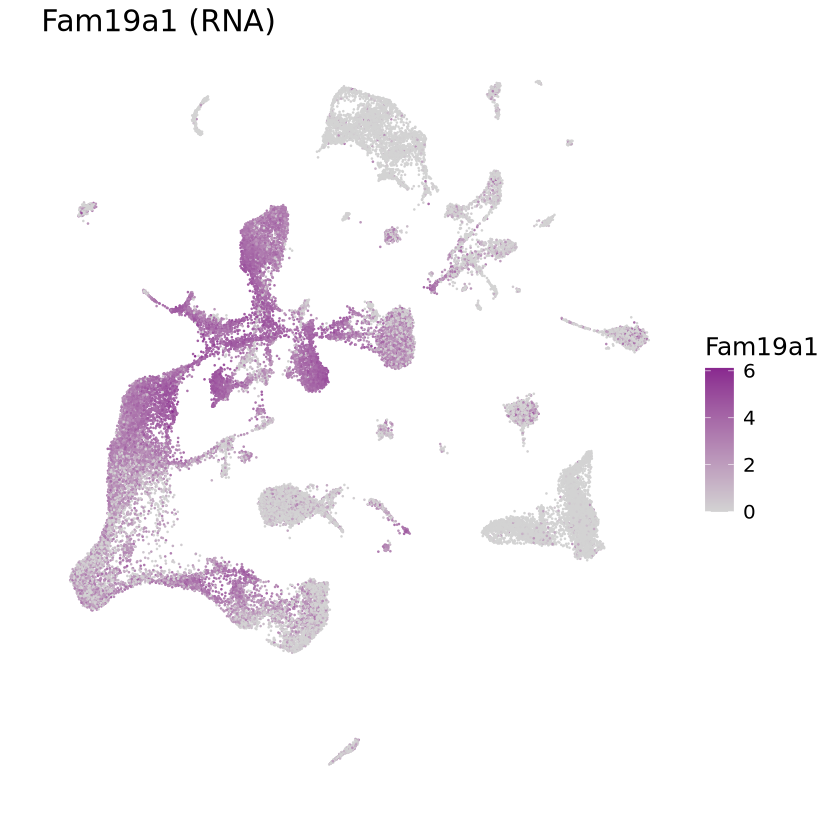

In [13]:
ggplot(RNA_final[,c("umap_1","umap_2","Fam19a1")], aes(x = umap_1, y = umap_2, color = Fam19a1)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "Fam19a1 (RNA)") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "lightgrey", high = "#89288F")

In [ ]:
read_mat <- function(group){
    data <- readRDS(sprintf("%s/03-%s_uniqueID.rds",indir,group))
    data <- t(data)
    colnames(data) <- mm10_genes$gene_name[match(colnames(data),mm10_genes$gene_id)]
    data <- cbind(UMAP,data)
    return(data)
}

In [15]:
hmCpG_final <- read_mat("5hmCpG")
hmCpG_final[1:4,1:6];dim(hmCpG_final)

,umap_1,umap_2,RP23-271O17.1,Gm26206,Xkr4,RP23-317L18.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,0.3333333,0.0000000,0.1993127,0.3749010
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,0.2125964,0.3549117,0.3181818,0.5000000
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,0.1950870,0.3225831,0.3534884,0.4765255
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,0.0000000,0.5000000,0.2906404,0.0000000


[1] 44608 49927

In [16]:
mCpG_final <- read_mat("5mCpG")
mCpG_final[1:4,1:6];dim(mCpG_final)

,umap_1,umap_2,RP23-271O17.1,Gm26206,Xkr4,RP23-317L18.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,0.8500000,0.8333333,0.8496042,1.0000000
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,0.9159863,1.0000000,0.8245614,0.9611582
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,0.7500000,1.0000000,0.9037433,1.0000000
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,1.0000000,1.0000000,0.8897638,1.0000000


[1] 44608 49927

In [17]:
true_CpG_final <- read_mat("trueCpG")
true_CpG_final[1:4,1:6];dim(true_CpG_final)

,umap_1,umap_2,RP23-271O17.1,Gm26206,Xkr4,RP23-317L18.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,0.5166667,0.8333333,0.6502915,0.6250990
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,0.7033899,0.6450883,0.5063796,0.4611582
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,0.5549130,0.6774169,0.5502549,0.5234745
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,1.0000000,0.5000000,0.5991234,1.0000000


[1] 44608 49927

In [18]:
hmCH_final <- read_mat("5hmCH")
hmCH_final[1:4,1:6];dim(hmCH_final)

,umap_1,umap_2,RP23-271O17.1,Gm26206,Xkr4,RP23-317L18.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,0.000000000,0.006172840,0.005910543,0.00000000
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,0.005701917,0.006719219,0.018499218,0.00000000
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,0.000000000,0.000000000,0.018423160,0.04032258
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,0.000000000,0.000000000,0.003291639,0.00000000


[1] 44608 49927

In [19]:
mCH_final <- read_mat("5mCH")
mCH_final[1:4,1:6];dim(mCH_final)

,umap_1,umap_2,RP23-271O17.1,Gm26206,Xkr4,RP23-317L18.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,0.03262956,0.01298701,0.014618933,0.020408163
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,0.03571429,0.01538462,0.006436143,0.012606973
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,0.01092896,0.02040816,0.018362558,0.037037037
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,0.02272727,0.00952381,0.013694775,0.008196721


[1] 44608 49927

In [20]:
true_CH_final <- read_mat("trueCH")
true_CH_final[1:4,1:6];dim(true_CH_final)

,umap_1,umap_2,RP23-271O17.1,Gm26206,Xkr4,RP23-317L18.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,0.03262956,0.006814173,0.00870839,0.020408163
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,0.03001237,0.008665396,0.00000000,0.012606973
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,0.01092896,0.020408163,0.00000000,0.000000000
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,0.02272727,0.009523810,0.01040314,0.008196721


[1] 44608 49927

接下来不同的plot_gene_expression函数定义就是调整legend的范围【6种甲基化】

In [21]:
plot_gene_expression <- function(gene_name,RNA_low,RNA_high) {
    
    data_frames <- list(
        RNA_final = RNA_final,
        hmCpG_final = hmCpG_final,
        mCpG_final = mCpG_final,
        true_CpG_final = true_CpG_final,
        hmCH_final = hmCH_final,
        mCH_final = mCH_final,
        true_CH_final = true_CH_final
    )

    for (df_name in names(data_frames)) {
        if (!(gene_name %in% colnames(data_frames[[df_name]]))) {
            warning(paste("Gene", gene_name, "not found in", df_name))
            return(NULL)
        }
    }
    
    RNA_final[[gene_name]] <- pmin(pmax(RNA_final[[gene_name]], RNA_low), RNA_high)
    hmCpG_final[[gene_name]] <- pmin(pmax(hmCpG_final[[gene_name]], 0.25), 0.40)
    mCpG_final[[gene_name]] <- pmin(pmax(mCpG_final[[gene_name]], 0.3), 1)
    true_CpG_final[[gene_name]] <- pmin(pmax(true_CpG_final[[gene_name]], 0.3), 1)
    hmCH_final[[gene_name]] <- pmin(pmax(hmCH_final[[gene_name]], 0), 0.05)
    mCH_final[[gene_name]] <- pmin(pmax(mCH_final[[gene_name]], 0), 0.05)
    true_CH_final[[gene_name]] <- pmin(pmax(true_CH_final[[gene_name]], 0), 0.05)
    
    p1 <- ggplot(RNA_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(RNA)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "lightgrey", high = "#89288F",limits = c(RNA_low, RNA_high),breaks = c(RNA_low, RNA_high))

    pp1 <- p1 + theme(legend.position = "none")
    legend_p1 <- get_legend(p1)

    p2 <- ggplot(hmCpG_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5hmCG)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.25, 0.40),breaks = c(0.25, 0.40))

    pp2 <- p2 + theme(legend.position = "none")
    legend_p2 <- get_legend(p2)

    p3 <- ggplot(mCpG_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5mCG+5hmCG)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.3, 1),breaks = c(0.3, 1))

    pp3 <- p3 + theme(legend.position = "none")
    legend_p3 <- get_legend(p3)

    p4 <- ggplot(true_CpG_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5mCG)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.3, 1),breaks = c(0.3, 1))

    pp4 <- p4 + theme(legend.position = "none")
    legend_p4 <- get_legend(p4)

    p5 <- ggplot(hmCH_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5hmCH)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#75D054FF",limits = c(0, 0.05),breaks = c(0, 0.05))

    pp5 <- p5 + theme(legend.position = "none")
    legend_p5 <- get_legend(p5)

    p6 <- ggplot(mCH_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5mCH+5hmCH)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#75D054FF",limits = c(0, 0.05),breaks = c(0, 0.05))

    pp6 <- p6 + theme(legend.position = "none")
    legend_p6 <- get_legend(p6)

    p7 <- ggplot(true_CH_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5mCH)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#75D054FF",limits = c(0, 0.05),breaks = c(0, 0.05))

    pp7 <- p7 + theme(legend.position = "none")
    legend_p7 <- get_legend(p7)
    
    gpp1 <- arrangeGrob(pp1, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp2 <- arrangeGrob(pp2, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp3 <- arrangeGrob(pp3, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp4 <- arrangeGrob(pp4, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp5 <- arrangeGrob(pp5, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp6 <- arrangeGrob(pp6, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp7 <- arrangeGrob(pp7, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    
    glegend_p1 <- arrangeGrob(legend_p1, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p2 <- arrangeGrob(legend_p2, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p3 <- arrangeGrob(legend_p3, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p4 <- arrangeGrob(legend_p4, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p5 <- arrangeGrob(legend_p5, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p6 <- arrangeGrob(legend_p6, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p7 <- arrangeGrob(legend_p7, heights = unit(3, "inches"), widths = unit(3, "inches"))

    combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, gpp4, gpp5, gpp6, gpp7, 
                                glegend_p1, glegend_p2, glegend_p3, glegend_p4, glegend_p5, glegend_p6, glegend_p7, ncol = 7, nrow = 2)
    return(combined_plot)
}

In [ ]:
# dir.create("07-plot_20250206")

In [22]:
library(cowplot)
library(gridExtra)
library(ggplot2)

Warning message:
“程辑包‘cowplot’是用R版本4.3.2 来建造的”

载入程辑包：‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [ ]:
ggsave(sprintf("%s/Ex_Fam19a1.pdf",outdir), 
       plot_gene_expression("Fam19a1",0,6), 
       width = 43, height = 20)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box")

In [ ]:
ggsave(sprintf("%s/Ex_Cadps2.pdf",outdir), 
       plot_gene_expression("Cadps2",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(sprintf("%s/Ex_Ndst4.pdf",outdir), 
       plot_gene_expression("Ndst4",0,4.5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(sprintf("%s/Ex_Tshz2.pdf",outdir), 
       plot_gene_expression("Tshz2",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(sprintf("%s/In_Gad2.pdf",outdir), 
       plot_gene_expression("Gad2",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(sprintf("%s/In_Erbb4.pdf",outdir), 
       plot_gene_expression("Erbb4",0,6), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/In_Nxph1.pdf"), 
       plot_gene_expression("Nxph1",0,5.5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/In_Rarb.pdf"), 
       plot_gene_expression("Rarb",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/Cdh18.pdf"), 
       plot_gene_expression("Cdh18",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [32]:
plot_gene_expression1 <- function(gene_name,RNA_low,RNA_high) {
    
    data_frames <- list(
        RNA_final = RNA_final,
        hmCpG_final = hmCpG_final,
        mCpG_final = mCpG_final,
        true_CpG_final = true_CpG_final,
        hmCH_final = hmCH_final,
        mCH_final = mCH_final,
        true_CH_final = true_CH_final
    )

    for (df_name in names(data_frames)) {
        if (!(gene_name %in% colnames(data_frames[[df_name]]))) {
            warning(paste("Gene", gene_name, "not found in", df_name))
            return(NULL)
        }
    }
    
    RNA_final[[gene_name]] <- pmin(pmax(RNA_final[[gene_name]], RNA_low), RNA_high)
    hmCpG_final[[gene_name]] <- pmin(pmax(hmCpG_final[[gene_name]], 0.25), 0.40)
    mCpG_final[[gene_name]] <- pmin(pmax(mCpG_final[[gene_name]], 0.4), 1)
    true_CpG_final[[gene_name]] <- pmin(pmax(true_CpG_final[[gene_name]], 0.4), 1)
    hmCH_final[[gene_name]] <- pmin(pmax(hmCH_final[[gene_name]], 0), 0.05)
    mCH_final[[gene_name]] <- pmin(pmax(mCH_final[[gene_name]], 0), 0.05)
    true_CH_final[[gene_name]] <- pmin(pmax(true_CH_final[[gene_name]], 0), 0.05)
    
    p1 <- ggplot(RNA_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(RNA)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "lightgrey", high = "#89288F",limits = c(RNA_low, RNA_high),breaks = c(RNA_low, RNA_high))

    pp1 <- p1 + theme(legend.position = "none")
    legend_p1 <- get_legend(p1)

    p2 <- ggplot(hmCpG_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5hmCG)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.25, 0.40),breaks = c(0.25, 0.40))

    pp2 <- p2 + theme(legend.position = "none")
    legend_p2 <- get_legend(p2)

    p3 <- ggplot(mCpG_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5mCG+5hmCG)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.4, 1),breaks = c(0.4, 1))

    pp3 <- p3 + theme(legend.position = "none")
    legend_p3 <- get_legend(p3)

    p4 <- ggplot(true_CpG_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5mCG)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.4, 1),breaks = c(0.4, 1))

    pp4 <- p4 + theme(legend.position = "none")
    legend_p4 <- get_legend(p4)

    p5 <- ggplot(hmCH_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5hmCH)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#75D054FF",limits = c(0, 0.05),breaks = c(0, 0.05))

    pp5 <- p5 + theme(legend.position = "none")
    legend_p5 <- get_legend(p5)

    p6 <- ggplot(mCH_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5mCH+5hmCH)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#75D054FF",limits = c(0, 0.05),breaks = c(0, 0.05))

    pp6 <- p6 + theme(legend.position = "none")
    legend_p6 <- get_legend(p6)

    p7 <- ggplot(true_CH_final[,c("umap_1","umap_2",gene_name)], aes_string(x = "umap_1", y = "umap_2", color = gene_name)) +
        geom_point(size=0.3) +
        labs(x = "", y = "",title = paste(gene_name, "(5mCH)")) +
        theme_minimal() +
        theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
              axis.ticks = element_blank()) +
        scale_color_gradient(low = "darkblue", high = "#75D054FF",limits = c(0, 0.05),breaks = c(0, 0.05))

    pp7 <- p7 + theme(legend.position = "none")
    legend_p7 <- get_legend(p7)
    
    gpp1 <- arrangeGrob(pp1, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp2 <- arrangeGrob(pp2, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp3 <- arrangeGrob(pp3, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp4 <- arrangeGrob(pp4, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp5 <- arrangeGrob(pp5, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp6 <- arrangeGrob(pp6, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    gpp7 <- arrangeGrob(pp7, heights = unit(6.2, "inches"), widths = unit(6, "inches"))
    
    glegend_p1 <- arrangeGrob(legend_p1, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p2 <- arrangeGrob(legend_p2, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p3 <- arrangeGrob(legend_p3, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p4 <- arrangeGrob(legend_p4, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p5 <- arrangeGrob(legend_p5, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p6 <- arrangeGrob(legend_p6, heights = unit(3, "inches"), widths = unit(3, "inches"))
    glegend_p7 <- arrangeGrob(legend_p7, heights = unit(3, "inches"), widths = unit(3, "inches"))

    combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, gpp4, gpp5, gpp6, gpp7, 
                                glegend_p1, glegend_p2, glegend_p3, glegend_p4, glegend_p5, glegend_p6, glegend_p7, ncol = 7, nrow = 2)
    return(combined_plot)
}

In [ ]:
dir.create(paste0(outdir,"/adjust/"))

In [ ]:
ggsave(paste0(outdir,"/adjust/Ex_Fam19a1.pdf"), 
       plot_gene_expression1("Fam19a1",0,6), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/adjust/Ex_Cadps2.pdf"), 
       plot_gene_expression1("Cadps2",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/adjust/Ex_Ndst4.pdf"), 
       plot_gene_expression1("Ndst4",0,4.5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/adjust/Ex_Tshz2.pdf"), 
       plot_gene_expression1("Tshz2",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/adjust/In_Gad2.pdf"), 
       plot_gene_expression1("Gad2",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/adjust/In_Erbb4.pdf"), 
       plot_gene_expression1("Erbb4",0,6), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/adjust/In_Nxph1.pdf"), 
       plot_gene_expression1("Nxph1",0,5.5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/adjust/In_Rarb.pdf"), 
       plot_gene_expression1("Rarb",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re

In [ ]:
ggsave(paste0(outdir,"/adjust/Cdh18.pdf"), 
       plot_gene_expression1("Cdh18",0,5), 
       width = 43, height = 20)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; re